In [3]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Activation, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

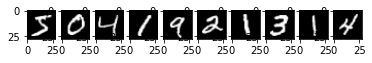

In [5]:
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(train_images[i], "gray")
plt.show()

In [6]:
print(train_labels[0:10])

[5 0 4 1 9 2 1 3 1 4]


In [7]:
train_images = train_images.reshape((train_images.shape[0], 784))
test_images = test_images.reshape((test_images.shape[0], 784))

In [8]:
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [9]:
model = Sequential()
model.add(Dense(256, activation='sigmoid', input_shape=(784,))) # 入力層
model.add(Dense(128, activation='sigmoid')) # 隠れ層
model.add(Dropout(rate=0.5)) # ドロップアウト
model.add(Dense(10, activation='softmax')) # 出力層

In [10]:
model.compile(loss='categorical_crossentropy', optimizer=SGD(lr=0.1), metrics=['acc'])

/opt/anaconda3/lib/python3.8/site-packages/keras/optimizers/optimizer_v2/gradient_descent.py:108: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


In [11]:
history = model.fit(train_images, train_labels, batch_size=500, 
    epochs=5, validation_split=0.2)

Epoch 1/5
96/96 [==============================] - 1s 7ms/step - loss: 1.6971 - acc: 0.4450 - val_loss: 0.9957 - val_acc: 0.8225
Epoch 2/5
96/96 [==============================] - 1s 5ms/step - loss: 0.9415 - acc: 0.7337 - val_loss: 0.6081 - val_acc: 0.8772
Epoch 3/5
96/96 [==============================] - 1s 6ms/step - loss: 0.6822 - acc: 0.8110 - val_loss: 0.4518 - val_acc: 0.8972
Epoch 4/5
96/96 [==============================] - 1s 6ms/step - loss: 0.5533 - acc: 0.8516 - val_loss: 0.3738 - val_acc: 0.9087
Epoch 5/5
96/96 [==============================] - 1s 6ms/step - loss: 0.4850 - acc: 0.8673 - val_loss: 0.3340 - val_acc: 0.9133


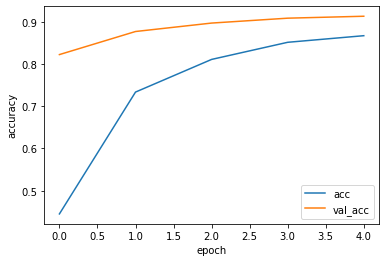

In [12]:
plt.plot(history.history['acc'], label='acc')
plt.plot(history.history['val_acc'], label='val_acc')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='best')
plt.show()

In [13]:
history.history

{'loss': [1.6971205472946167,
  0.9414755702018738,
  0.6821693778038025,
  0.5532560348510742,
  0.4849550724029541],
 'acc': [0.4449999928474426,
  0.7336666584014893,
  0.8110416531562805,
  0.851604163646698,
  0.8672500252723694],
 'val_loss': [0.9957338571548462,
  0.6080518364906311,
  0.4517970383167267,
  0.3737955391407013,
  0.3340213894844055],
 'val_acc': [0.8224999904632568,
  0.8771666884422302,
  0.8971666693687439,
  0.9087499976158142,
  0.9133333563804626]}

In [14]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('loss: {:.3f}\nacc: {:.3f}'.format(test_loss, test_acc ))

313/313 [==============================] - 1s 2ms/step - loss: 0.3378 - acc: 0.9121
loss: 0.338
acc: 0.912


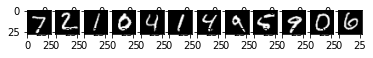

In [20]:
for i in range(12):
    plt.subplot(1, 12, i+1)
    plt.imshow(test_images[i].reshape((28, 28)), "gray")
plt.show()

In [41]:
test_predictions = model.predict(test_images[0:12])
test_predictions = np.argmax(test_predictions, axis=1)
print(test_predictions)

1/1 [==============================] - 0s 19ms/step
[7 2 1 0 4 1 4 9 6 9 0 6]


In [29]:
np.argmax(test_labels[0:12], axis=1)

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6])

In [35]:
test_labels[0:12]

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]], dtype=float32)

In [77]:
np.argmax(model.predict(train_images[0:10]), axis=1)

1/1 [==============================] - 0s 17ms/step


array([3, 0, 4, 1, 9, 2, 1, 3, 1, 4])

In [78]:
np.argmax(train_labels[0:10], axis=1)

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])

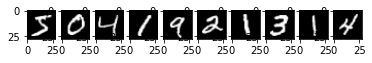

In [80]:
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(train_images[i].reshape((28, 28)), "gray")
plt.show()